<a href="https://colab.research.google.com/github/Subhamnation/Computer_Vision_Masterclass_projects/blob/main/Recognition_of_gestures_and_actions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computer Vision Masterclass - Recognition of gestures and actions


## Detecting body points

### Importing the libraries

In [ ]:
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import numpy as np

### Loading the image

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
image = cv2.imread('/content/drive/MyDrive/Computer Vision Masterclass/Examples/Images/megan.jpg')

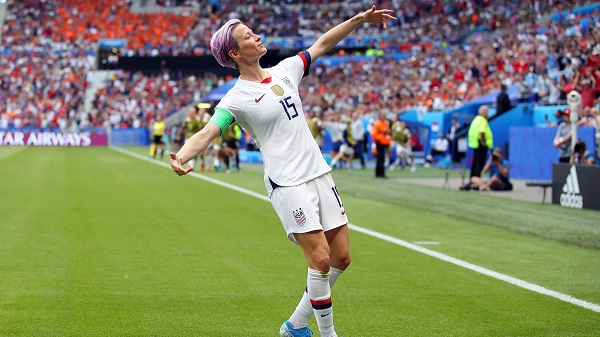

In [ ]:
cv2_imshow(image)

In [ ]:
image.shape

((337, 600, 3), 606600)

In [ ]:
 image.shape[0] * image.shape[1] * 3 # TOtal amout of the data in the image

606600

In [ ]:
type(image)

numpy.ndarray

In [ ]:
# Mean subtraction: https://www.pyimagesearch.com/2017/11/06/deep-learning-opencvs-blobfromimage-works/
image_blob = cv2.dnn.blobFromImage(image = image, scalefactor = 1.0 / 255,
                                   size = (image.shape[1], image.shape[0]))

In [ ]:
type(image_blob), image_blob.shape # batch

(numpy.ndarray, (1, 3, 337, 600))

### Loading the pre-trained neural network

- Caffe Deep Learning framework: https://caffe.berkeleyvision.org/

In [ ]:
network = cv2.dnn.readNetFromCaffe('/content/drive/MyDrive/Computer Vision Masterclass/Weights/pose_deploy_linevec_faster_4_stages.prototxt',
                                   '/content/drive/MyDrive/Computer Vision Masterclass/Weights/pose_iter_160000.caffemodel')

In [ ]:
network.getLayerNames()

('conv1_1',
 'relu1_1',
 'conv1_2',
 'relu1_2',
 'pool1_stage1',
 'conv2_1',
 'relu2_1',
 'conv2_2',
 'relu2_2',
 'pool2_stage1',
 'conv3_1',
 'relu3_1',
 'conv3_2',
 'relu3_2',
 'conv3_3',
 'relu3_3',
 'conv3_4',
 'relu3_4',
 'pool3_stage1',
 'conv4_1',
 'relu4_1',
 'conv4_2',
 'relu4_2',
 'conv4_3_CPM',
 'relu4_3_CPM',
 'conv4_4_CPM',
 'relu4_4_CPM',
 'conv5_1_CPM_L1',
 'relu5_1_CPM_L1',
 'conv5_1_CPM_L2',
 'relu5_1_CPM_L2',
 'conv5_2_CPM_L1',
 'relu5_2_CPM_L1',
 'conv5_2_CPM_L2',
 'relu5_2_CPM_L2',
 'conv5_3_CPM_L1',
 'relu5_3_CPM_L1',
 'conv5_3_CPM_L2',
 'relu5_3_CPM_L2',
 'conv5_4_CPM_L1',
 'relu5_4_CPM_L1',
 'conv5_4_CPM_L2',
 'relu5_4_CPM_L2',
 'conv5_5_CPM_L1',
 'conv5_5_CPM_L2',
 'concat_stage2',
 'Mconv1_stage2_L1',
 'Mrelu1_stage2_L1',
 'Mconv1_stage2_L2',
 'Mrelu1_stage2_L2',
 'Mconv2_stage2_L1',
 'Mrelu2_stage2_L1',
 'Mconv2_stage2_L2',
 'Mrelu2_stage2_L2',
 'Mconv3_stage2_L1',
 'Mrelu3_stage2_L1',
 'Mconv3_stage2_L2',
 'Mrelu3_stage2_L2',
 'Mconv4_stage2_L1',
 'Mrelu4_sta

In [ ]:
len(network.getLayerNames())

127

### Predicting body points

In [ ]:
network.setInput(image_blob)
output = network.forward()

In [ ]:
# 44 -> related to the points that were detected
# (43, 75) -> information about the location
output.shape

(1, 44, 43, 75)

In [ ]:
position_width = output.shape[3]
position_heigth = output.shape[2]

In [ ]:
position_width

75

In [ ]:
(image.shape[1] * 28) / 75

224.0

In [ ]:
num_points = 15
points = []
threshold = 0.1
for i in range(num_points):
  print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14


In [ ]:
for i in range(num_points):
  #print(i)
  confidence_map = output[0, i, :, :]
  print(confidence_map) # candidate points
  print(len(confidence_map))

[[0.00055962 0.00058117 0.00053579 ... 0.00046494 0.00052144 0.00070126]
 [0.00056341 0.00061412 0.00052243 ... 0.00043261 0.00049986 0.00065831]
 [0.00053554 0.00056641 0.00048143 ... 0.00043169 0.00049813 0.00059231]
 ...
 [0.00054603 0.0005327  0.00055443 ... 0.0004957  0.00050947 0.00049164]
 [0.00056263 0.00054248 0.00058617 ... 0.00050225 0.00053838 0.00052778]
 [0.00057272 0.00055983 0.00060435 ... 0.00051735 0.00056315 0.00057202]]
43
[[0.00111267 0.00121808 0.00114181 ... 0.00090227 0.0010741  0.00183263]
 [0.00109335 0.00143292 0.00105185 ... 0.00084134 0.0009794  0.00163177]
 [0.00112441 0.00127546 0.00095223 ... 0.0008397  0.00097065 0.00120474]
 ...
 [0.00107108 0.00105736 0.00109277 ... 0.00099074 0.00102576 0.0009806 ]
 [0.00115377 0.00106191 0.00114098 ... 0.00097911 0.00106342 0.00103366]
 [0.00112932 0.00109654 0.00118373 ... 0.00100781 0.00110869 0.00112275]]
43
[[0.00060168 0.00077594 0.00064453 ... 0.00041856 0.0006952  0.00212014]
 [0.00067747 0.00130531 0.0005576

In [ ]:
num_points = 15
points = []
threshold = 0.1
for i in range(num_points):
  #print(i)
  confidence_map = output[0, i, :, :]
  #print(confidence_map) # candidate points
  #print(len(confidence_map))
  _, confidence, _, point = cv2.minMaxLoc(confidence_map)
  print(confidence)
  print(point)

0.7554603219032288
(28, 3)
0.9123886227607727
(31, 8)
0.6697733998298645
(29, 12)
0.7503755688667297
(26, 16)
0.7385104298591614
(22, 19)
0.7186108231544495
(35, 8)
0.7754004597663879
(40, 5)
0.7418562769889832
(45, 2)
0.5037312507629395
(36, 23)
0.7334707379341125
(40, 32)
0.6221854090690613
(40, 41)
0.52265465259552
(39, 21)
0.9403212070465088
(42, 32)
0.7596975564956665
(37, 39)
0.7704715728759766
(35, 16)


In [ ]:
# minMaxLoc: https://docs.opencv.org/master/d2/de8/group__core__array.html#gab473bf2eb6d14ff97e89b355dac20707
num_points = 15
points = []
threshold = 0.1
for i in range(num_points):
  #print(i)
  confidence_map = output[0, i, :, :]
  #print(confidence_map) # candidate points
  #print(len(confidence_map))
  _, confidence, _, point = cv2.minMaxLoc(confidence_map)
  #print(confidence)
  #print(point)

  x = int((image.shape[1] * point[0]) / position_width)
  y = int((image.shape[0] * point[1]) / position_heigth)
  print(x,y)
  if confidence > threshold:
    cv2.circle(image, (x, y), 5, (0,255,0), thickness = -1)
    cv2.putText(image, '{}'.format(i), (x,y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255))
    points.append((x,y))
  else:
    points.append(None)

224 23
248 62
232 94
208 125
176 148
280 62
320 39
360 15
288 180
320 250
320 321
312 164
336 250
296 305
280 125


In [ ]:
points

[(224, 23),
 (248, 62),
 (232, 94),
 (208, 125),
 (176, 148),
 (280, 62),
 (320, 39),
 (360, 15),
 (288, 180),
 (320, 250),
 (320, 321),
 (312, 164),
 (336, 250),
 (296, 305),
 (280, 125)]

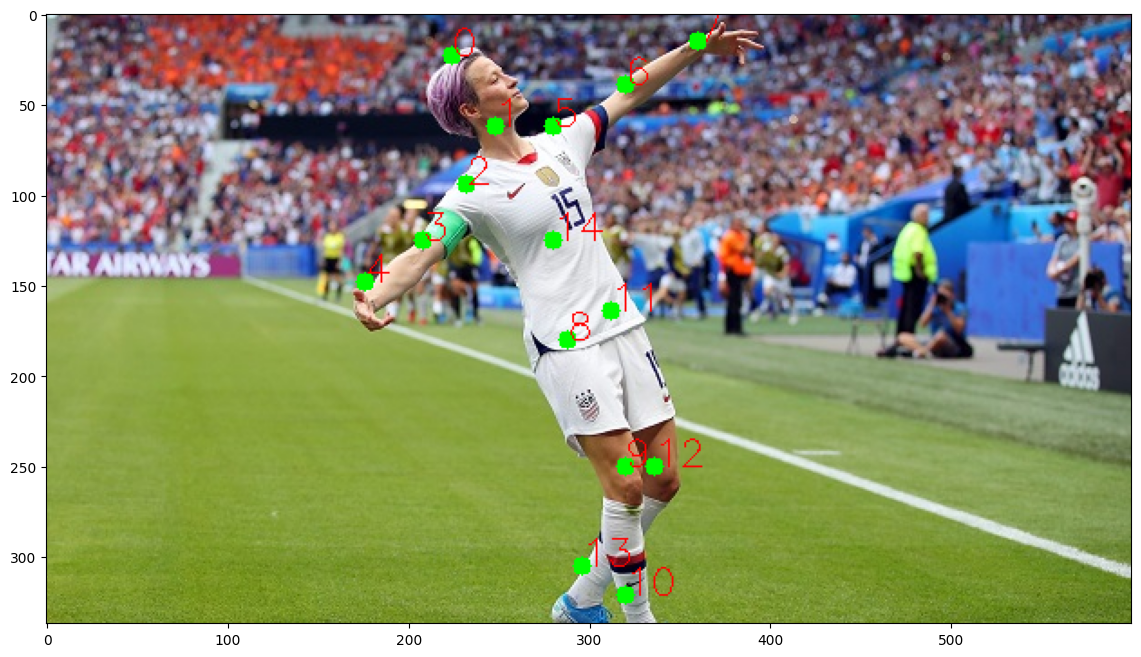

In [ ]:
plt.figure(figsize=(14,10))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB));

In [ ]:
point_connections = [[0,1], [1,2], [2,3], [3,4], [1,5], [5,6], [6,7],[1,14],
                     [14,8], [8,9], [9,10], [14,11], [11,12], [12,13]]

In [ ]:
point_connections

[[0, 1],
 [1, 2],
 [2, 3],
 [3, 4],
 [1, 5],
 [5, 6],
 [6, 7],
 [1, 14],
 [14, 8],
 [8, 9],
 [9, 10],
 [14, 11],
 [11, 12],
 [12, 13]]

In [ ]:
for connection in point_connections:
  print(connection)
  partA = connection[0]
  partB = connection[1]
  print(partA, partB)
  if points[partA] and points[partB]:
    cv2.line(image, points[partA], points[partB], (255,0,0))

[0, 1]
0 1
[1, 2]
1 2
[2, 3]
2 3
[3, 4]
3 4
[1, 5]
1 5
[5, 6]
5 6
[6, 7]
6 7
[1, 14]
1 14
[14, 8]
14 8
[8, 9]
8 9
[9, 10]
9 10
[14, 11]
14 11
[11, 12]
11 12
[12, 13]
12 13


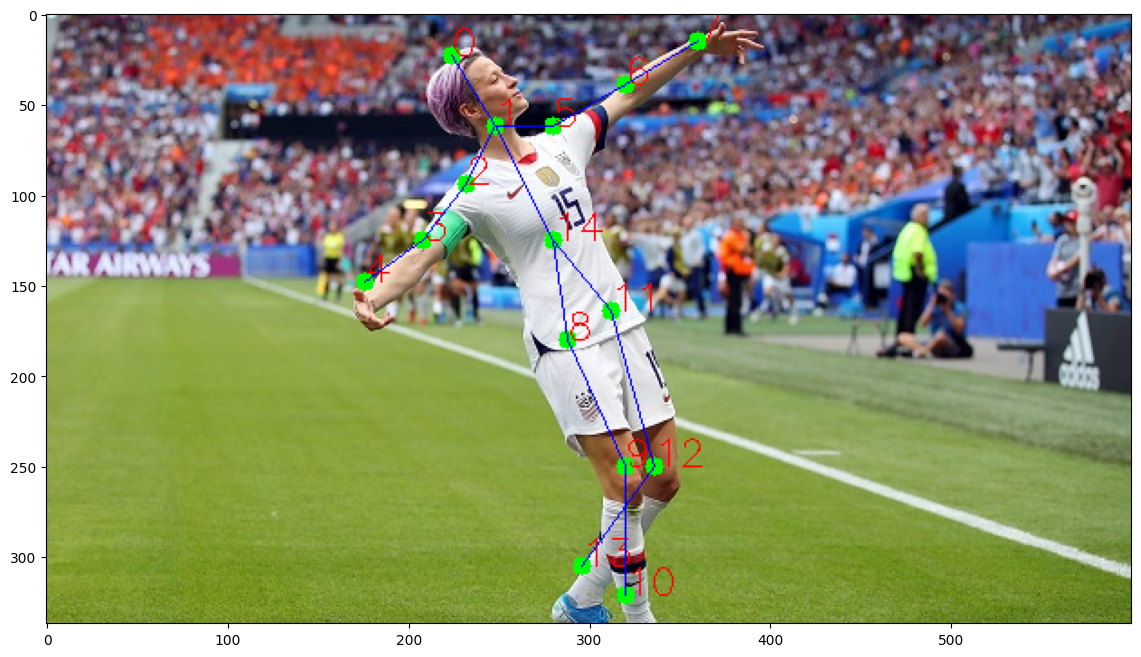

In [ ]:
plt.figure(figsize=(14,10))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB));

## Detecting movements (arms above the head)

### Arms above the head in images

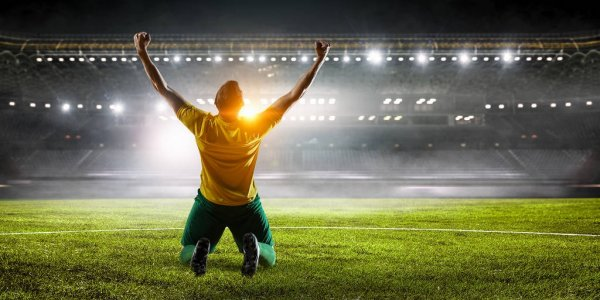

In [ ]:
image2 = cv2.imread('/content/drive/MyDrive/Computer Vision Masterclass/Examples/Images/player.jpg')
cv2_imshow(image2)

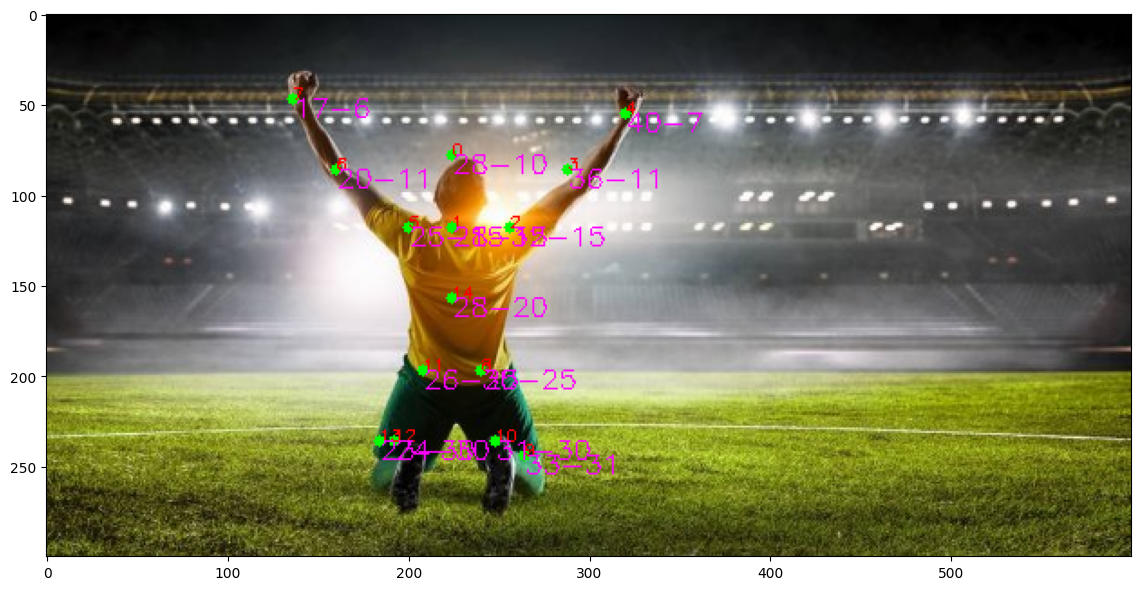

In [ ]:
image_blob2 = cv2.dnn.blobFromImage(image = image2, scalefactor = 1.0 / 255,
                                   size = (image2.shape[1], image2.shape[0]))
network.setInput(image_blob2)
output2 = network.forward()
position_width = output2.shape[3]
position_height = output2.shape[2]
num_points = 15
points = []
threshold = 0.1
for i in range(num_points):
  confidence_map = output2[0, i, :, :]
  _, confidence, _, point = cv2.minMaxLoc(confidence_map)
  x = int((image2.shape[1] * point[0]) / position_width)
  y = int((image2.shape[0] * point[1]) / position_height)

  if confidence > threshold:
    cv2.circle(image2, (x, y), 3, (0,255,0), thickness = -1)
    cv2.putText(image2, "{}".format(i), (x, y), cv2.FONT_HERSHEY_SIMPLEX, .3, (0, 0, 255))
    cv2.putText(image2, '{}-{}'.format(point[0], point[1]), (x, y + 10), cv2.FONT_HERSHEY_SIMPLEX, .5, (255,0,255))
    points.append((x, y))
  else:
    points.append(None)

plt.figure(figsize = [14,10])
plt.imshow(cv2.cvtColor(image2, cv2.COLOR_BGR2RGB));

In [ ]:
def verify_arms_up(points):
  head, right_wrist, left_wrist = 0, 0, 0
  for i, point in enumerate(points):
    #print(i, point)
    if i == 0:
      head = point[1]
    elif i == 4:
      right_wrist = point[1]
    elif i == 7:
      left_wrist = point[1]

  #print(head, right_wrist, left_wrist)
  if right_wrist < head and left_wrist < head:
    return True
  else:
    return False

In [ ]:
verify_arms_up(points)

True

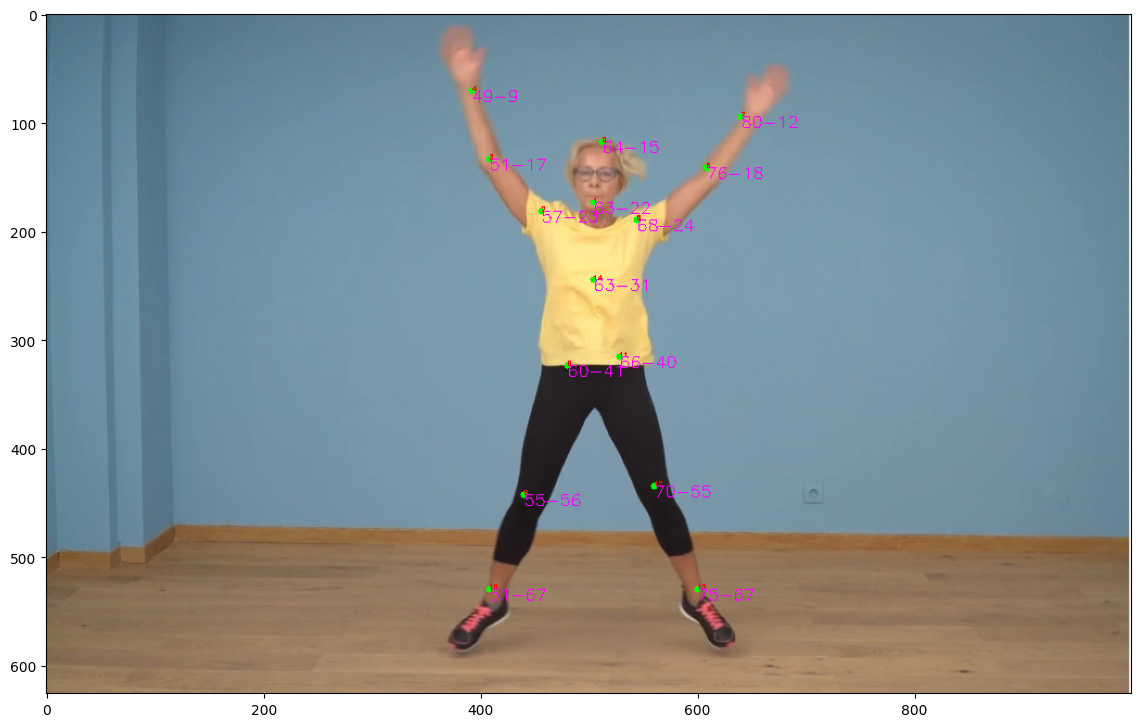

In [ ]:
image = cv2.imread('/content/drive/MyDrive/Computer Vision Masterclass/Examples/Images/jump.jpg')
image_blob = cv2.dnn.blobFromImage(image = image, scalefactor = 1.0 / 255, size = (image.shape[1], image.shape[0]))
network.setInput(image_blob)
output = network.forward()
position_width = output.shape[3]
position_height = output.shape[2]
num_points = 15
points = []
threshold = 0.1
for i in range(num_points):
  confidence_map = output[0, i, :, :]
  _, confidence, _, point = cv2.minMaxLoc(confidence_map)
  x = int((image.shape[1] * point[0]) / position_width)
  y = int((image.shape[0] * point[1]) / position_height)

  if confidence > threshold:
    cv2.circle(image, (x, y), 3, (0,255,0), thickness = -1)
    cv2.putText(image, "{}".format(i), (x, y), cv2.FONT_HERSHEY_SIMPLEX, .2, (0, 0, 255))
    cv2.putText(image, "{}-{}".format(point[0], point[1]), (x, y + 10), cv2.FONT_HERSHEY_SIMPLEX, .5, (255, 0, 255))
    points.append((x, y))
  else:
    points.append(None)

plt.figure(figsize = [14,10])
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB));

In [ ]:
def verify_legs_apart(points):
  left_hip, rigth_hip = 0, 0
  left_ankle, right_ankle = 0, 0

  for i, point in enumerate(points):
    if i == 11:
      left_hip = point[0]
    elif i == 8:
      rigth_hip = point[0]
    elif i == 13:
      left_ankle = point[0]
    elif i == 10:
      rigth_ankle = point[0]

  if (left_ankle > left_hip) and (rigth_ankle < rigth_hip):
    return True
  else:
    return False

In [ ]:
verify_legs_apart(points)

True

### Arms above the head in videos

- VideoWriter_fourcc: https://www.programcreek.com/python/example/89348/cv2.VideoWriter_fourcc

In [ ]:
video = '/content/drive/MyDrive/Computer Vision Masterclass/Videos/gesture1.mp4'
capture = cv2.VideoCapture(video)
connected, frame = capture.read()

In [ ]:
connected

True

In [ ]:
frame.shape

(1080, 808, 3)

In [ ]:
result = '/content/drive/MyDrive/Computer Vision Masterclass/Videos/gesture1_result.mp4'
save_video = cv2.VideoWriter(result, cv2.VideoWriter_fourcc(*'XVID'),  10, (frame.shape[1], frame.shape[0]))

In [ ]:
# https://stackoverflow.com/questions/5217519/what-does-opencvs-cvwaitkey-function-do
threshold = 0.1
while cv2.waitKey(1) < 0:
  connected, frame = capture.read()

  if not connected:
    break

  image_blob = cv2.dnn.blobFromImage(image = frame, scalefactor = 1.0 / 255, size = (256, 256))
  network.setInput(image_blob)
  output = network.forward()
  position_height = output.shape[2]
  position_width = output.shape[3]

  num_points = 15
  points = []
  for i in range(num_points):
    confidence_map = output[0, i, :, :]
    _, confidence, _, point = cv2.minMaxLoc(confidence_map)
    x = int((frame.shape[1] * point[0]) / position_width)
    y = int((frame.shape[0] * point[1]) / position_height)
    if confidence > threshold:
      cv2.circle(frame, (x, y), 5, (0,255,0), thickness = -1)
      cv2.putText(frame, "{}".format(i), (x, y), cv2.FONT_HERSHEY_SIMPLEX, .7, (0, 0, 255))
      points.append((x, y))
    else:
      points.append(None)

  for connection in point_connections:
    partA = connection[0]
    partB = connection[1]
    if points[partA] and points[partB]:
      cv2.line(frame, points[partA], points[partB], (255,0,0))

  if verify_arms_up(points) == True and verify_legs_apart(points) == True:
    cv2.putText(frame, 'Complete', (50,200), cv2.FONT_HERSHEY_COMPLEX, 3, (0,0,255))

  cv2_imshow(frame)
  save_video.write(frame)
save_video.release()